# S1 Backtest — Monthly universe reshuffle (H-015)

Same STAR parameters as notebook 08. Predictions and engineered features come from
`03_models/s1_equities/model_tests/extras/s1_monthly_reshuffle.ipynb`.

**Universe rule (buffered 100/120):** on the first week-start of each calendar month,
rank feature-complete PIT S&P 500 names by trailing 20-day ADV. A name **enters** at
rank ≤ 100 and only **leaves** once its rank passes 120. Membership is held constant
until the next monthly reshuffle. The Ridge model was retrained on this monthly
cross-section.

Primary metric: **OOS Sharpe** after the shared IS end (baseline train-panel dates).
Do not retune STAR parameters on OOS.


## 0. Imports & Config


In [1]:
import os
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

warnings.filterwarnings("ignore")

ROOT = os.path.abspath(os.getcwd())
while not os.path.isdir(os.path.join(ROOT, "01_data", "ingestion")):
    parent = os.path.dirname(ROOT)
    if parent == ROOT:
        break
    ROOT = parent
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from backtest.s1_equities.costs import DEFAULT_COSTS, cost_summary
from backtest.s1_equities.portfolio import (
    WEIGHT_EQUAL,
    WEIGHT_INV_VOL,
    WEIGHT_RANK,
    WEIGHT_SCORE,
)
from backtest.s1_equities.report import (
    compare_segments,
    concentration_vs_returns,
    ic_horizon_decay,
    ic_stability_summary,
    losing_months_summary,
    plot_concentration,
    plot_cost_drag_vs_turnover,
    plot_drawdown,
    plot_equity_overlay,
    plot_feature_attrition,
    plot_losing_months,
    plot_rolling_ic,
    plot_rolling_sharpe,
    regime_performance,
    split_period_returns,
    spy_weekly_open_returns,
    turnover_drag_summary,
    write_tearsheet_pdf,
)
from backtest.s1_equities.runner import run_backtest, summarize_periods
from backtest.s1_equities.stops import parse_stop_star
from backtest.s1_equities.signals import (
    TIMING_MON_OPEN_FRI_CLOSE,
    TIMING_MON_OPEN_MON_OPEN,
    default_backtest_paths,
    is_mask_from_preds,
    load_ohlc_panels,
    load_predictions,
    prediction_path_for_timing,
    score_matrix,
)
from data.processing.feature_implementation.realized_vol import DEFAULT_OPEN_VOL_WINDOW
from models.s1_equities.training_common import (
    LABEL_COL,
    LABEL_COL_MON_FRI,
    date_ic_series,
    feature_attrition_summary,
)
from risk.analytics.s1_equities.signal_conviction import parse_ic_scale_star
from risk.analytics.s1_equities.vol_targeting import parse_vol_target_star

PATHS = default_backtest_paths(ROOT)
ART = PATHS["artifacts"]
os.makedirs(ART, exist_ok=True)

# --- Set from notebooks 01 / 02 / 03 / 05 / 06 / 07 (suggested values printed there) ---
N_STAR = 15
TIMING_STAR = TIMING_MON_OPEN_MON_OPEN  # or TIMING_MON_OPEN_FRI_CLOSE
WEIGHT_STAR = WEIGHT_INV_VOL  # or WEIGHT_SCORE / WEIGHT_RANK / WEIGHT_INV_VOL
# From notebook 03 §5 when WEIGHT_STAR is inv_vol (ignored otherwise)
INV_VOL_WINDOW_STAR = 42
STOP_STAR = "pct_20"  # "none" | "atr_14_3" from 05 | "pct_5" from 06
VT_STAR = 'vt_bayes_0.9_10_q0.75_db0.05'
IC_STAR = 'ic_k15_0.94_f0.25_c1.25'

RESHUFFLE_ART = os.path.join(
    ROOT, "03_models", "s1_equities", "model_tests", "extras", "artifacts"
)
RESHUFFLE_FEATURES = os.path.join(
    RESHUFFLE_ART, "s1_reshuffle_engineered_features_full.parquet"
)
PRED_PATH = os.path.join(
    PATHS["model_dir"], "s1_reshuffle_ridge_predictions.parquet"
)
PATHS["features"] = RESHUFFLE_FEATURES
BASELINE_PRED_PATH = prediction_path_for_timing(
    default_backtest_paths(ROOT), TIMING_STAR
)

FEATURE_COLS_ATTRITION = [
    "raw_momentum_252_5",
    "smart_residual_mom_189_42",
    "rel_downside_beta_252",
    "rel_upside_beta_63",
    "smart_beta_hml_252",
    "downside_beta_42",
    "upside_beta_42",
    "size_mom_126",
    "val_roc_pb_252",
    "val_roc_pe_252",
    "log_mcap",
    "val_mom_dist_252_21",
    "gross_profitability",
    "filing_clock_expected_until",
    "short_flow_ratio",
    "market_corr",
    "beta_mkt_interact",
    "abnormal_volume",
    "gdelt_tone_x_attention_21",
    "gdelt_attention_5",
]

print(f"N_STAR={N_STAR} (notebook parameter)")
print(f"TIMING_STAR={TIMING_STAR} (notebook parameter)")
print(f"WEIGHT_STAR={WEIGHT_STAR} (notebook parameter)")
print(f"INV_VOL_WINDOW_STAR={INV_VOL_WINDOW_STAR} (used when WEIGHT_STAR=inv_vol)")
print(f"STOP_STAR={STOP_STAR} (notebook parameter)")
print(f"VT_STAR={VT_STAR} (notebook parameter)")
print(f"IC_STAR={IC_STAR} (notebook parameter)")
print(f"predictions={PRED_PATH}")
print(f"features={PATHS['features']}")
print(f"baseline_preds={BASELINE_PRED_PATH}")
STOP_CFG = parse_stop_star(STOP_STAR)
VT_CFG = parse_vol_target_star(VT_STAR)
IC_CFG = parse_ic_scale_star(IC_STAR)
display(pd.Series(cost_summary(DEFAULT_COSTS), name="bps").to_frame())


N_STAR=15 (notebook parameter)
TIMING_STAR=mon_open_mon_open (notebook parameter)
WEIGHT_STAR=inv_vol (notebook parameter)
INV_VOL_WINDOW_STAR=42 (used when WEIGHT_STAR=inv_vol)
STOP_STAR=pct_20 (notebook parameter)
VT_STAR=vt_bayes_0.9_10_q0.75_db0.05 (notebook parameter)
IC_STAR=ic_k15_0.94_f0.25_c1.25 (notebook parameter)
predictions=c:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\03_models\s1_equities\model_artifacts\s1_reshuffle_ridge_predictions.parquet
features=c:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\03_models\s1_equities\model_tests\extras\artifacts\s1_reshuffle_engineered_features_full.parquet
baseline_preds=c:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\03_models\s1_equities\model_artifacts\s1_linear_slim_ffill_is_predictions.parquet


,bps
commission_bps,0.0
regulatory_bps,0.5
half_spread_bps,5.0
open_slippage_bps,10.0
close_slippage_bps,5.0
short_borrow_bps,0.0
open_one_way_bps,15.5
close_one_way_bps,10.5


## 1. Load & run full-sample backtest


In [2]:
preds = load_predictions(PRED_PATH)
scores = score_matrix(preds)
is_mask = is_mask_from_preds(preds)
opens, highs, lows, closes = load_ohlc_panels(PATHS["features"], tickers=list(scores.columns))

label_col = LABEL_COL_MON_FRI if TIMING_STAR == TIMING_MON_OPEN_FRI_CLOSE else LABEL_COL
ic_inputs = None
if IC_CFG.enabled:
    if label_col not in preds.columns:
        raise ValueError(f"predictions missing {label_col} for IC overlay")
    ics = date_ic_series(preds, "score", label_col=label_col)
    n_names = preds.groupby("date")["ticker"].nunique()
    n_names.index = pd.to_datetime(n_names.index)
    ic_inputs = pd.DataFrame({"ic": ics, "n_names": n_names}).sort_index()

result = run_backtest(
    scores,
    opens,
    closes,
    n=N_STAR,
    timing_mode=TIMING_STAR,
    weight_mode=WEIGHT_STAR,
    inv_vol_window=INV_VOL_WINDOW_STAR,
    costs=DEFAULT_COSTS,
    date_mask=None,  # full sample; split in reporting
    highs=highs,
    lows=lows,
    stop=STOP_CFG,
    vol_target=VT_CFG,
    ic_scale=IC_CFG,
    ic_inputs=ic_inputs,
)
print(
    f"periods={len(result.period_returns)}  "
    f"span={result.period_returns.index.min().date()} -> {result.period_returns.index.max().date()}"
)


periods=525  span=2016-07-05 -> 2026-07-20


## 2. IS vs OOS metrics


In [3]:
is_dates = is_mask.index[is_mask]
metrics = compare_segments(result, is_dates)
display(metrics)

# Explicit OOS-only summary line
oos = metrics.loc["OOS"]
print(
    f"OOS: Sharpe={oos['sharpe']:.3f}  AvgAnn={oos['avg_ann_return']:.3%}  "
    f"CAGR={oos['cagr']:.3%}  MaxDD={oos['max_drawdown']:.3%}  "
    f"periods={int(oos['n_periods'])}"
)
is_row = metrics.loc["IS"]
print(
    f"IS:  Sharpe={is_row['sharpe']:.3f}  AvgAnn={is_row['avg_ann_return']:.3%}  "
    f"CAGR={is_row['cagr']:.3%}  MaxDD={is_row['max_drawdown']:.3%}  "
    f"periods={int(is_row['n_periods'])}"
)


,n_periods,total_return,avg_ann_return,cagr,vol,sharpe,max_drawdown,win_rate,mean_return,sharpe_vbt,sortino_vbt,calmar_vbt,max_dd_vbt
segment,,,,,,,,,,,,,
IS,344,0.592448,0.072739,0.072864,0.068762,1.057838,-0.133895,0.569767,0.001399,1.057838,1.634320,0.544189,-0.133895
OOS,181,0.074187,0.022701,0.020773,0.065540,0.346376,-0.087564,0.541436,0.000437,0.346376,0.500935,0.237229,-0.087564
FULL,525,0.710587,0.055488,0.054611,0.067686,0.819782,-0.133895,0.560000,0.001067,0.819782,1.238891,0.407868,-0.133895


OOS: Sharpe=0.346  AvgAnn=2.270%  CAGR=2.077%  MaxDD=-8.756%  periods=181
IS:  Sharpe=1.058  AvgAnn=7.274%  CAGR=7.286%  MaxDD=-13.389%  periods=344


## 3. Performance overview

Headline equity / risk visuals only. Deep-dive diagnostics are in section 4.

### 3.1 Equity (net vs gross)


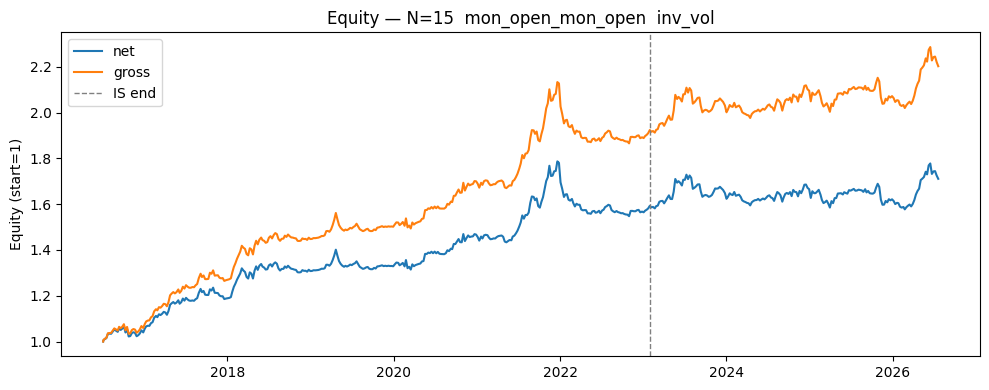

In [4]:
is_end = is_dates.max()
_, oos_rets = split_period_returns(result.period_returns, is_dates)

fig = plot_equity_overlay(
    {"net": result.equity, "gross": result.equity_gross},
    title=f"Equity — N={N_STAR}  {TIMING_STAR}  {WEIGHT_STAR}",
    is_end=is_end,
)
plt.show()


### 3.2 Drawdown

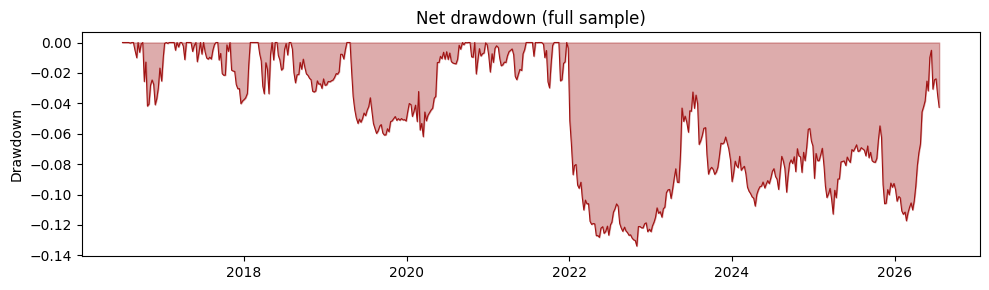

In [5]:
fig = plot_drawdown(result.equity, title="Net drawdown (full sample)")
plt.show()


### 3.3 OOS rolling Sharpe

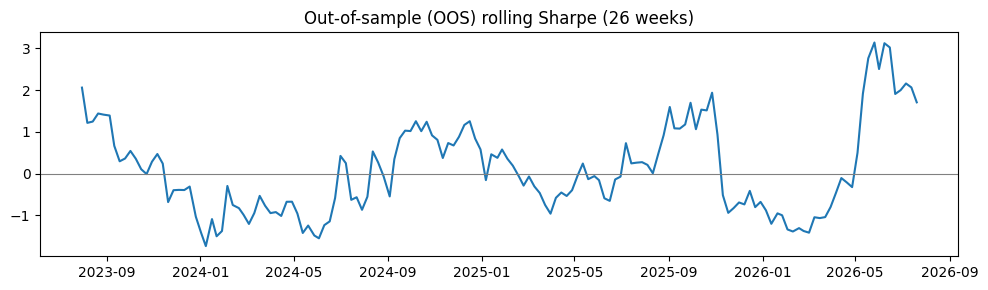

In [6]:
fig = plot_rolling_sharpe(
    oos_rets,
    window=26,
    title="Out-of-sample (OOS) rolling Sharpe (26 weeks)",
)
plt.show()


## 4. Underperformance diagnostics

Descriptive OOS diagnostics only — do not retune parameters on this slice.


### 4.1 Losing months

Compound weekly OOS returns to calendar months; list worst months and yearly hit-rate.


,monthly_return
2025-11-01,-0.053812
2023-09-01,-0.028643
2025-03-01,-0.020409
2024-03-01,-0.019568
2026-07-01,-0.018521
2025-02-01,-0.018129
2023-08-01,-0.016883
2026-02-01,-0.016773
2023-12-01,-0.012496
2026-01-01,-0.010456


,pct_months_up
year,
2023,0.636364
2024,0.666667
2025,0.500000
2026,0.571429


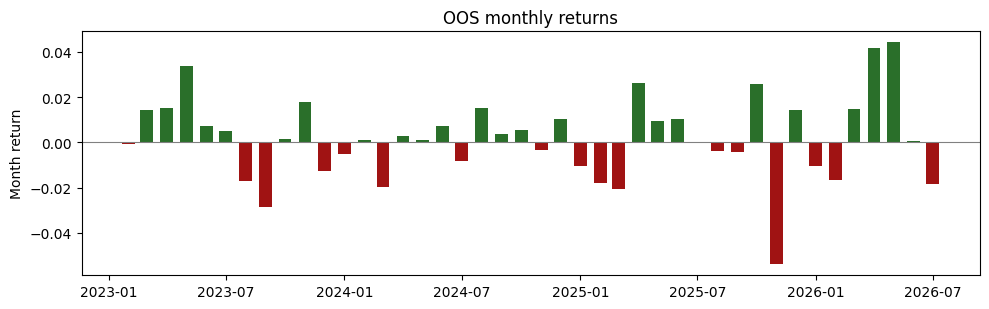

In [7]:
lm = losing_months_summary(oos_rets)
display(lm["worst"])
display(lm["pct_months_up_by_year"].to_frame())
fig = plot_losing_months(lm["monthly"], title="OOS monthly returns")
plt.show()


### 4.2 Regimes

SPY open-to-open weekly return (Up/Down) and trailing-26w SPY vol terciles.
Vol cutpoints are fit on **IS** trailing vol only, then applied to OOS.


In [8]:
spy_w = spy_weekly_open_returns(result.period_returns.index)
regimes = regime_performance(oos_rets, spy_w, is_dates)
print("Vol cutpoints (IS):")
display(regimes["vol_cutpoints"].to_frame("value"))
print("By market direction:")
display(regimes["market"])
print("By vol tercile:")
display(regimes["vol"])


Vol cutpoints (IS):


,value
q33,0.014929
q66,0.026653


By market direction:


,n,mean_return,total_return,sharpe,win_rate
regime,,,,,
Down,72,-0.005312,-0.320245,-4.569357,0.263889
Up,109,0.004234,0.580255,4.120928,0.724771


By vol tercile:


,n,mean_return,total_return,sharpe,win_rate
regime,,,,,
Mid,110,0.000798,0.085981,0.582615,0.536364
Low,44,-0.000828,-0.037268,-0.715548,0.568182
High,27,0.001024,0.027430,1.118826,0.518519


### 4.3 IC stability and decay

Per-date Spearman IC of score vs the timing label; rolling mean IC; horizon decay.


,mean_ic,std_ic,icir,n
IS,0.049407,0.236228,0.209150,344.0
OOS,0.040293,0.283264,0.142246,182.0


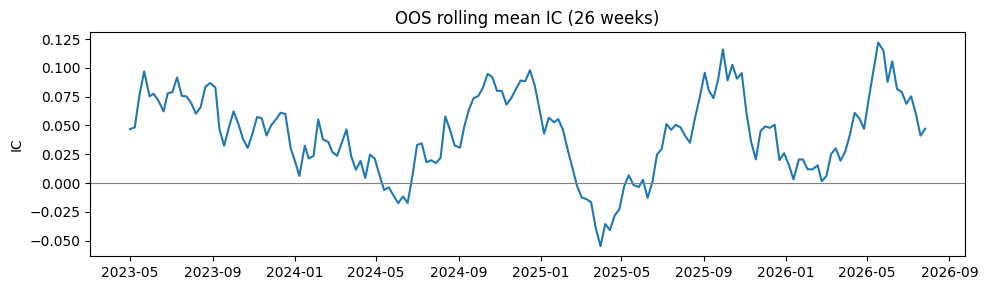

,mean_ic,std_ic,icir,n
horizon,,,,
fwd_ret_1,0.050752,0.257597,0.197021,526
fwd_ret_5,0.046254,0.253260,0.182633,526
fwd_ret_21,0.075584,0.237708,0.317971,523


In [9]:
LABEL_STAR = (
    LABEL_COL_MON_FRI
    if TIMING_STAR == TIMING_MON_OPEN_FRI_CLOSE
    else LABEL_COL
)
ic = ic_stability_summary(preds, is_dates, label_col=LABEL_STAR)
display(ic["segment"])
fig = plot_rolling_ic(ic["ics_oos"], title="OOS rolling mean IC (26 weeks)")
plt.show()
decay = ic_horizon_decay(preds, PATHS["features"])
display(decay)


### 4.4 Turnover drag

Gross vs net edge and cost drag versus one-way turnover.


,value
mean_turnover,0.227497
median_turnover,0.222261
mean_cost_drag,0.000352
mean_cost_over_abs_gross,0.052136
sharpe_net,0.346376
sharpe_gross,0.627371
corr_turnover_drag,0.999939


,turnover,cost_drag,ret_net,ret_gross
turnover,1.000000,0.999939,-0.140236,-0.121153
cost_drag,0.999939,1.000000,-0.140152,-0.121068
ret_net,-0.140236,-0.140152,1.000000,0.999815
ret_gross,-0.121153,-0.121068,0.999815,1.000000


Mean turnover=0.2275  Median=0.2223


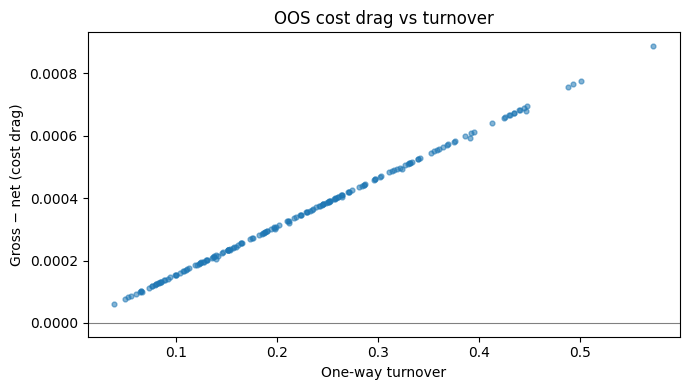

In [10]:
drag = turnover_drag_summary(result, is_dates)
display(drag["summary"].to_frame("value"))
display(drag["corr"])
print(
    f"Mean turnover={drag['summary']['mean_turnover']:.4f}  "
    f"Median={drag['summary']['median_turnover']:.4f}"
)
fig = plot_cost_drag_vs_turnover(drag["frame"])
plt.show()


### 4.5 Weight concentration

Per-date max |w| / HHI on OOS entry weights; correlation with period returns.


,value
n_dates,181.000000
max_abs_w_mean,0.059207
max_abs_w_p50,0.058068
max_abs_w_p95,0.073977
max_abs_w_max,0.087391
min_abs_w_mean,0.015030
hhi_mean,0.036618
long_max_share_mean,0.114982
long_max_share_max,0.174782
short_max_share_mean,0.102772


,hhi,max_abs_w,ret
hhi,1.000000,0.796455,0.117597
max_abs_w,0.796455,1.000000,0.177887
ret,0.117597,0.177887,1.000000


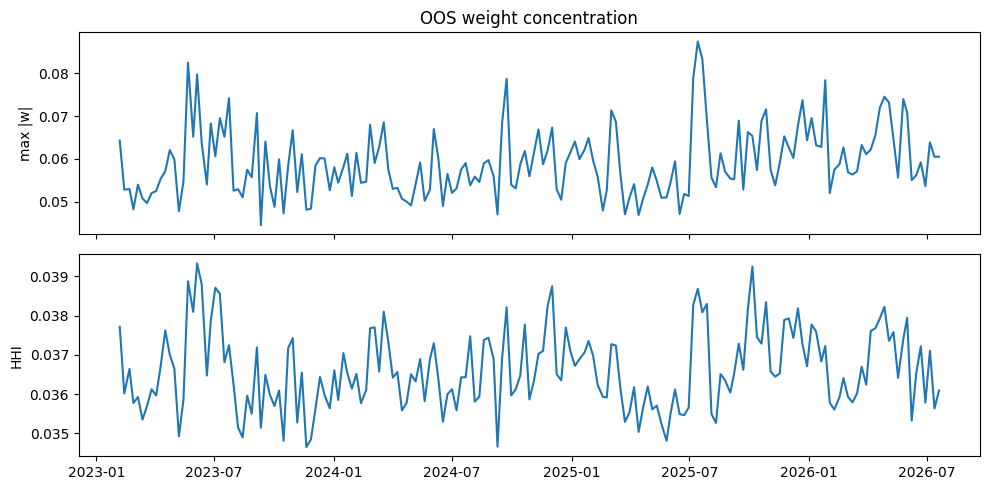

In [11]:
conc = concentration_vs_returns(
    result.entry_weights.reindex(oos_rets.index),
    oos_rets,
)
display(conc["summary"].to_frame("value"))
display(conc["corr"])
fig = plot_concentration(conc["stats"], title="OOS weight concentration")
plt.show()


### 4.6 Feature attrition

How many membership names survive complete-case feature coverage, and which features bind.


,n_candidates,n_complete,n_dropped
count,526.000000,526.000000,526.000000
mean,91.766160,91.456274,0.309886
std,4.757398,4.937803,0.873404
min,63.000000,63.000000,0.000000
25%,92.000000,91.000000,0.000000
50%,93.000000,93.000000,0.000000
75%,94.000000,94.000000,0.000000
max,96.000000,96.000000,10.000000


,total_blame,exclusive_blame
val_roc_pe_252,0.002155,0.503067
downside_beta_42,0.000994,0.239264
upside_beta_42,0.000414,0.122699
gross_profitability,0.000331,0.000000
smart_residual_mom_189_42,0.000000,0.000000
raw_momentum_252_5,0.000000,0.000000
smart_beta_hml_252,0.000000,0.000000
rel_upside_beta_63,0.000000,0.000000
size_mom_126,0.000000,0.000000
rel_downside_beta_252,0.000000,0.000000


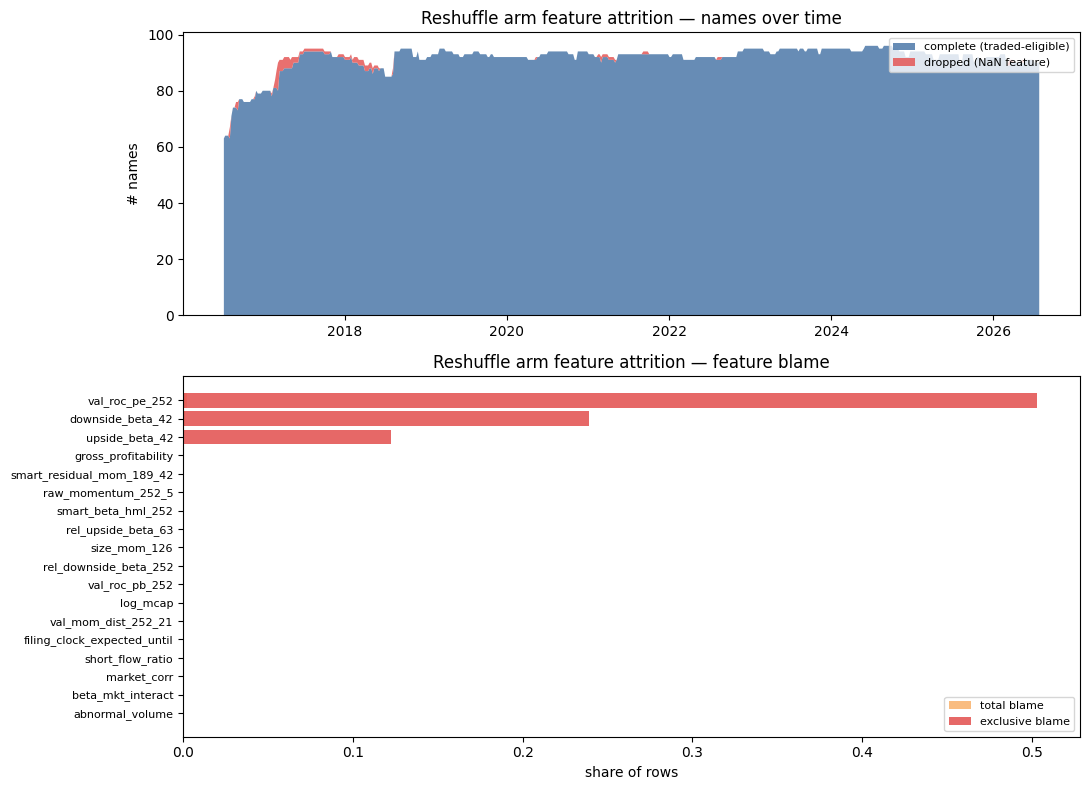

In [12]:
_feat = pd.read_parquet(PATHS["features"])
_feat["date"] = pd.to_datetime(_feat["date"])
_feat["ticker"] = _feat["ticker"].astype(str).str.strip().str.upper()
_pred_keys = set(
    zip(pd.to_datetime(preds["date"]), preds["ticker"].astype(str).str.upper())
)
_feat["_cand"] = [
    (d, t) in _pred_keys
    for d, t in zip(pd.to_datetime(_feat["date"]), _feat["ticker"])
]
attrition_summary = feature_attrition_summary(
    _feat,
    [c for c in FEATURE_COLS_ATTRITION if c in _feat.columns],
    candidate_mask=_feat["_cand"],
    ffill=True,
)
display(attrition_summary["by_date"].describe())
display(
    pd.concat(
        [attrition_summary["total_blame"], attrition_summary["exclusive_blame"]],
        axis=1,
    ).head(20)
)
fig = plot_feature_attrition(
    attrition_summary, title="Reshuffle arm feature attrition"
)
plt.show()


## 5. Save tearsheet PDF

Exports metrics, performance overview, and underperformance diagnostics.


In [13]:
pdf_path = os.path.join(
    ART, f"tearsheet_reshuffle_n{N_STAR}_{TIMING_STAR}_{WEIGHT_STAR}.pdf"
)
LABEL_STAR = (
    LABEL_COL_MON_FRI
    if TIMING_STAR == TIMING_MON_OPEN_FRI_CLOSE
    else LABEL_COL
)
write_tearsheet_pdf(
    pdf_path,
    result=result,
    is_dates=is_dates,
    metrics=metrics,
    title=f"S1 L/S N={N_STAR} {TIMING_STAR} {WEIGHT_STAR}",
    preds=preds,
    features_path=PATHS["features"],
    label_col=LABEL_STAR,
    attrition=attrition_summary,
)
print(f"saved {pdf_path}")


saved c:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\04_backtest\s1_equities\artifacts\tearsheet_reshuffle_n15_mon_open_mon_open_inv_vol.pdf


## 6. Paired OOS Sharpe vs static baseline

Both arms share week entry dates. Report OOS Sharpe difference with a bootstrap CI.


In [14]:
rng = np.random.default_rng(42)

base_preds = load_predictions(BASELINE_PRED_PATH)
base_scores = score_matrix(base_preds)
base_is = is_mask_from_preds(base_preds)
base_paths = default_backtest_paths(ROOT)
b_opens, b_highs, b_lows, b_closes = load_ohlc_panels(
    base_paths["features"], tickers=list(base_scores.columns)
)

base_ic_inputs = None
if IC_CFG.enabled:
    if label_col not in base_preds.columns:
        raise ValueError(f"baseline predictions missing {label_col} for IC overlay")
    base_ics = date_ic_series(base_preds, "score", label_col=label_col)
    base_n_names = base_preds.groupby("date")["ticker"].nunique()
    base_n_names.index = pd.to_datetime(base_n_names.index)
    base_ic_inputs = pd.DataFrame({"ic": base_ics, "n_names": base_n_names}).sort_index()

base_result = run_backtest(
    base_scores,
    b_opens,
    b_closes,
    n=N_STAR,
    timing_mode=TIMING_STAR,
    weight_mode=WEIGHT_STAR,
    inv_vol_window=INV_VOL_WINDOW_STAR,
    costs=DEFAULT_COSTS,
    date_mask=None,
    highs=b_highs,
    lows=b_lows,
    stop=STOP_CFG,
    vol_target=VT_CFG,
    ic_scale=IC_CFG,
    ic_inputs=base_ic_inputs,
)

_, reshuffle_oos = split_period_returns(result.period_returns, is_dates)
_, baseline_oos = split_period_returns(
    base_result.period_returns, base_is.index[base_is]
)
aligned = pd.concat(
    [reshuffle_oos.rename("reshuffle"), baseline_oos.rename("baseline")],
    axis=1,
).dropna()
print(f"paired OOS weeks={len(aligned)}")

def _sharpe(r: pd.Series, ppy: float = 52.0) -> float:
    r = r.dropna()
    if len(r) < 2:
        return float("nan")
    vol = float(r.std(ddof=1) * np.sqrt(ppy))
    mu = float(r.mean() * ppy)
    return mu / vol if vol > 1e-12 else float("nan")

s_r = _sharpe(aligned["reshuffle"])
s_b = _sharpe(aligned["baseline"])
delta = s_r - s_b
print(f"OOS Sharpe reshuffle={s_r:.3f}  baseline={s_b:.3f}  delta={delta:.3f}")

n_boot = 2000
diffs = []
n = len(aligned)
idx = np.arange(n)
for _ in range(n_boot):
    take = rng.choice(idx, size=n, replace=True)
    sample = aligned.iloc[take]
    diffs.append(_sharpe(sample["reshuffle"]) - _sharpe(sample["baseline"]))
diffs = np.asarray(diffs, dtype=float)
diffs = diffs[np.isfinite(diffs)]
lo, hi = np.quantile(diffs, [0.025, 0.975])
print(f"Bootstrap 95% CI for Sharpe delta: [{lo:.3f}, {hi:.3f}]  (n_boot={n_boot})")
display(aligned.describe())


paired OOS weeks=180
OOS Sharpe reshuffle=0.385  baseline=0.507  delta=-0.122
Bootstrap 95% CI for Sharpe delta: [-0.933, 0.653]  (n_boot=2000)


,reshuffle,baseline
count,180.000000,180.000000
mean,0.000485,0.000555
std,0.009090,0.007883
min,-0.033148,-0.031467
25%,-0.004513,-0.003607
50%,0.000455,0.000760
75%,0.005018,0.004292
max,0.033508,0.032545
